<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif;">
  <h1 style="margin:0; font-size:2.2em;">BSU Cursus: Web-Based Management System for Document Processing and Budget Monitoring in Academic and Student Organizations</h1>
  <h3 style="margin:8px 0 20px 0; color:#a8d8ea; font-weight:300;">CRISP-DM Framework · Python Implementation</h3>
  <hr style="border-color:#a8d8ea44;">
  <table style="color:white; width:100%; border:none;">
    <tr><td><b>Name</b></td><td>: <i>Johann Sebastian Beleno</i></td><td><b>Course / Section</b></td><td>: <i>BSIT BA 3202</i></td></tr>
    </td>
  </table>
</div>

# Phase 1 · Business Understanding
---

### 1.1 Problem Statement

> Student organizations and institutional units often struggle with inefficient budget utilization, inconsistent spending behavior, and limited visibility into financial risks across activities. This results in potential overspending, resource misallocation, and difficulty in planning sustainable organizational budgets.

### 1.2 Core Insight

> Predictive analytics applied to activity-based costing data reveals that organizational expenses are not randomly distributed but follow distinct behavioral patterns. Specifically, a subset of activities consistently exhibits high non-essential costs and cost inefficiencies, while historical spending trends show predictable seasonal spikes that can be forecasted using time-series modeling.

### 1.3 Recommendation

> Institutions should adopt a data-driven financial monitoring framework that combines spending behavior clustering, anomaly detection, and budget forecasting. High-risk spending activities should be flagged for review, organizational spending profiles should be used for budget allocation planning, and forecasted expenditure trends should guide proactive financial decision-making to improve transparency, efficiency, and resource optimization.

### 1.4 Problem Identification

> Organizations within academic institutions, including student groups and administrative units, handle multiple financial activities such as event funding, procurement, and operational support. However, these activities are often managed using fragmented tracking systems and reactive approval processes. As a result, inefficiencies in spending, delayed financial decisions, and lack of visibility into cost behavior patterns are common.

> In the context of the BSU Cursus Web-Based Management System, these challenges become more critical due to the increasing volume of student-led activities and the need for standardized, centralized financial monitoring. Without predictive insights, decision-makers are limited to historical reporting rather than forward-looking financial planning.

### 1.5 SDG Alignment

This study aligns with the following United Nations Sustainable Development Goals (SDGs):

*   SDG 4: Quality Education – By improving financial transparency and resource allocation in academic organizations, the system supports better access to student-led educational activities.
*   LSDG 9: Industry, Innovation, and Infrastructure – The integration of predictive analytics into institutional financial systems promotes innovation in administrative processes and digital transformation.
*   SDG 16: Peace, Justice, and Strong Institutions – By enabling data-driven oversight of financial activities, the system enhances transparency, accountability, and institutional governance.









### 1.6 Cost and Impact

The absence of predictive financial monitoring leads to measurable inefficiencies, including:

*   Uncontrolled or excessive spending in certain activities
*   Repetitive allocation of funds to low-impact or non-essential costs
*   Delays in identifying budget overruns until after completion of activities

Based on the activity-based costing dataset structure, a significant proportion of costs can be attributed to non-essential expenditures and variable operational inefficiencies. In practical terms, even a modest reduction in inefficient spending (e.g., 10–20%) across recurring organizational activities can translate into substantial budget savings and improved allocation of institutional resources.

These inefficiencies highlight the need for predictive models that can forecast spending behavior, identify anomalies, and classify financial risk before budget decisions are finalized.

### 1.7 Dataset Overview and Relevance to BSU Cursus

The dataset used in this study is an Activity-Based Costing dataset that contains detailed records of organizational operations, including cost drivers, activity types, departments, and financial breakdowns such as fixed cost, variable cost, total cost, potential savings, and non-essential costs. Each record represents a specific organizational activity and its associated financial impact, supported by both numerical and categorical attributes. This structure allows the dataset to capture not only the magnitude of expenses but also the operational context behind each cost.

In relation to the BSU Cursus system, the dataset closely aligns with the system’s core objectives of document processing, budget monitoring, and financial transparency for academic and student organizations. The cost-related attributes simulate budget allocation and utilization, while activity and department fields reflect organizational workflows similar to document routing and approval processes. Furthermore, variables such as potential savings and non-essential costs support the system’s goal of identifying inefficiencies and improving financial decision-making. Overall, the dataset serves as a suitable proxy for modeling organizational budgeting behavior within the BSU Cursus framework, enabling predictive analytics to support better resource management and administrative efficiency.

# Phase 2 · Data Understanding
---

### 2.1 Import Libraries

In [33]:
# =========================
# CORE DATA HANDLING
# =========================
import pandas as pd
import numpy as np

# =========================
# VISUALIZATION
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# PREPROCESSING / FEATURE ENGINEERING
# =========================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# =========================
# CLUSTERING (MODEL 1)
# K-Means for spending behavior segmentation
# =========================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =========================
# CLASSIFICATION (MODEL 2)
# Random Forest / classification evaluation
# =========================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# TIME SERIES FORECASTING (MODEL 3)
# SARIMA for budget usage forecasting
# =========================
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm

# =========================
# MODEL EVALUATION / METRICS
# =========================
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# UTILITIES
# =========================
import warnings
warnings.filterwarnings('ignore')

### 2.2 Load Dataset

In [34]:
# Load the Activity-Based Costing dataset
# This dataset will be adapted to represent BSU Cursus organizational financial activities
# Dataset provided by: https://www.kaggle.com/datasets/joe2016/activity-based-costing-dataset

df = pd.read_excel('/content/Activity_Based_Costing_Tire_Factory_20000_Records_June2024.xlsx', sheet_name='Sheet1')

# Display first few rows to verify successful loading
df.head()

,Activity,Cost Driver,Cost Driver Rate,Units of Activity,Total Cost,Fixed Cost,Variable Cost,Fixed/Variable Ratio,Activity Type,Department,Potential Savings,Non-Essential Costs,Cost Impact on Production Efficiency,Cost Pool,Date
0,Customer Service Support,Number of audits,4635,76,352260,28752,323508,"8.16% Fixed, 91.84% Variable",Support,R&D,1527,193,High,Manufacturing Overhead,2023-06-13
1,Energy Consumption,Kilowatt hours (kWh),2014,15,30210,10789,19421,"35.71% Fixed, 64.29% Variable",Support,Operations,4015,1615,Medium,Energy Costs,2023-05-10
2,Energy Consumption,Number of shipments,2654,22,58388,25896,32492,"44.35% Fixed, 55.65% Variable",Production,Customer Service,1992,1455,Low,Manufacturing Overhead,2024-01-27
3,Maintenance of Machinery,Kilowatt hours (kWh),2475,71,175725,26122,149603,"14.87% Fixed, 85.13% Variable",Development,Purchasing,4744,824,Medium,Product Development,2024-02-13
4,Environmental Compliance,Number of audits,2610,33,86130,4783,81347,"5.55% Fixed, 94.45% Variable",Production,Operations,615,956,Low,Environmental Compliance,2024-10-03


### 2.3 Initial Structural Inspection

In [35]:
# Check dataset structure, data types, and missing values
# Helps understand data readiness for preprocessing
df.info()

# Check column names for initial understanding of variables
print(df.columns)

# Check for missing values in each column
# Important for data cleaning decisions
print(df.isnull().sum())

# View dataset shape (rows, columns)
# Confirms dataset size for modeling readiness
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Activity                              20000 non-null  object
 1   Cost Driver                           20000 non-null  object
 2   Cost Driver Rate                      20000 non-null  int64 
 3   Units of Activity                     20000 non-null  int64 
 4   Total Cost                            20000 non-null  int64 
 5   Fixed Cost                            20000 non-null  int64 
 6   Variable Cost                         20000 non-null  int64 
 7   Fixed/Variable Ratio                  20000 non-null  object
 8   Activity Type                         20000 non-null  object
 9   Department                            20000 non-null  object
 10  Potential Savings                     20000 non-null  int64 
 11  Non-Essential Costs         

### 2.4 Descriptive Statistics

In [36]:
# Summary statistics for numerical variables
# Helps understand distribution, scale, and potential outliers
print("\n" + "="*60)
print("NUMERICAL SUMMARY STATISTICS")
print("="*60)
print(df.describe())


# Include categorical overview using value counts
# Helps identify dominant categories in activities
print("\n" + "="*60)
print("TOP ACTIVITY COUNTS")
print("="*60)
print(df['Activity'].value_counts().head())


# Helps identify dominant categories in departments
print("\n" + "="*60)
print("TOP DEPARTMENT COUNTS")
print("="*60)
print(df['Department'].value_counts().head())


NUMERICAL SUMMARY STATISTICS
       Cost Driver Rate  Units of Activity     Total Cost     Fixed Cost  \
count      20000.000000       20000.000000   20000.000000   20000.000000   
mean        2506.549350          52.573600  131810.977750   32978.950800   
std         1432.358812          27.817787  110024.401426   36867.536111   
min           50.000000           5.000000     320.000000       2.000000   
25%         1255.750000          28.000000   41507.500000    6333.750000   
50%         2501.500000          52.000000  100439.500000   19203.500000   
75%         3744.000000          77.000000  199589.500000   46784.000000   
max         5000.000000         100.000000  499600.000000  239858.000000   

       Variable Cost  Potential Savings  Non-Essential Costs  
count   20000.000000       20000.000000         20000.000000  
mean    98832.026950        2507.285050          1001.771500  
std     86138.556825        1447.429396           575.959776  
min       170.000000           1.

#### Descriptive Statistics

> The dataset contains 20,000 operational cost records with significant variation in financial activity levels. The average total cost per activity is approximately 131,811, with some activities reaching as high as 499,600, indicating the presence of both low-cost and high-cost operational events. The wide standard deviation in total cost and variable cost suggests inconsistent spending behavior across activities and departments.

> The mean fixed cost is substantially lower than the mean variable cost, implying that most operational expenses are driven by activity volume rather than static overhead expenses. Additionally, the average non-essential cost of approximately 1,002 indicates that a noticeable portion of expenses may be attributed to inefficient or unnecessary spending, which supports the relevance of financial risk analysis and classification modeling.

> Potential savings values averaging around 2,507 further suggest opportunities for budget optimization and cost reduction strategies within organizational operations.

### 2.5 Visual Exploratory Data Analysis

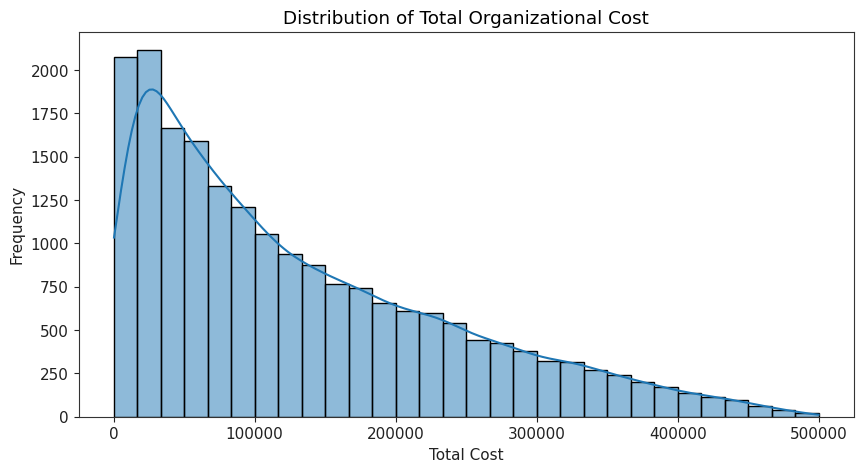

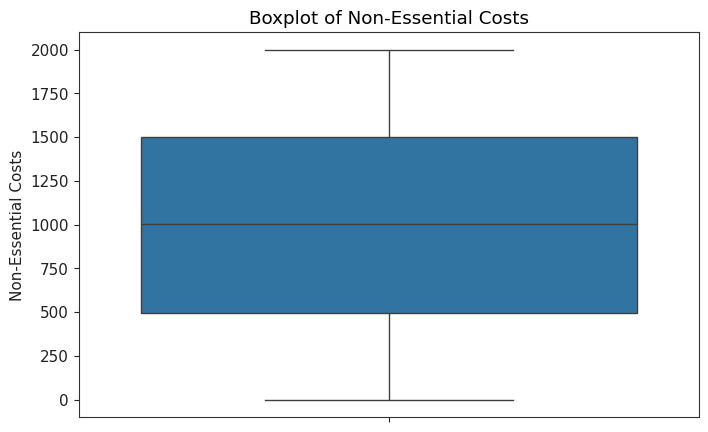

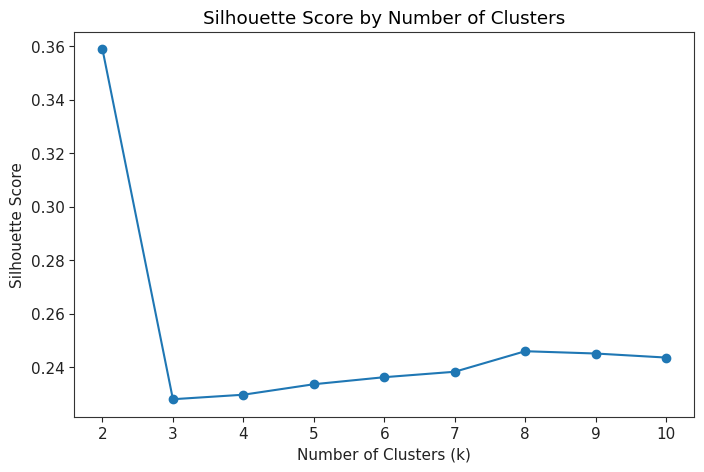

In [37]:
# =========================
# VISUAL EXPLORATORY DATA ANALYSIS
# Histogram, Boxplot, and Silhouette Analysis
# =========================

# -------------------------
# HISTOGRAM: TOTAL COST
# Shows distribution of organizational expenses
# -------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['Total Cost'], bins=30, kde=True)

plt.title('Distribution of Total Organizational Cost')
plt.xlabel('Total Cost')
plt.ylabel('Frequency')
plt.show()


# -------------------------
# BOXPLOT: NON-ESSENTIAL COSTS
# Helps identify outliers and extreme spending behavior
# -------------------------
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Non-Essential Costs'])

plt.title('Boxplot of Non-Essential Costs')
plt.ylabel('Non-Essential Costs')
plt.show()


# -------------------------
# SILHOUETTE ANALYSIS FOR K-MEANS
# Helps determine optimal number of clusters
# -------------------------

# Select clustering features
cluster_features = df[[
    'Total Cost',
    'Fixed Cost',
    'Variable Cost',
    'Potential Savings',
    'Non-Essential Costs'
]]

# Scale features before clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# Test different cluster counts
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')

plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

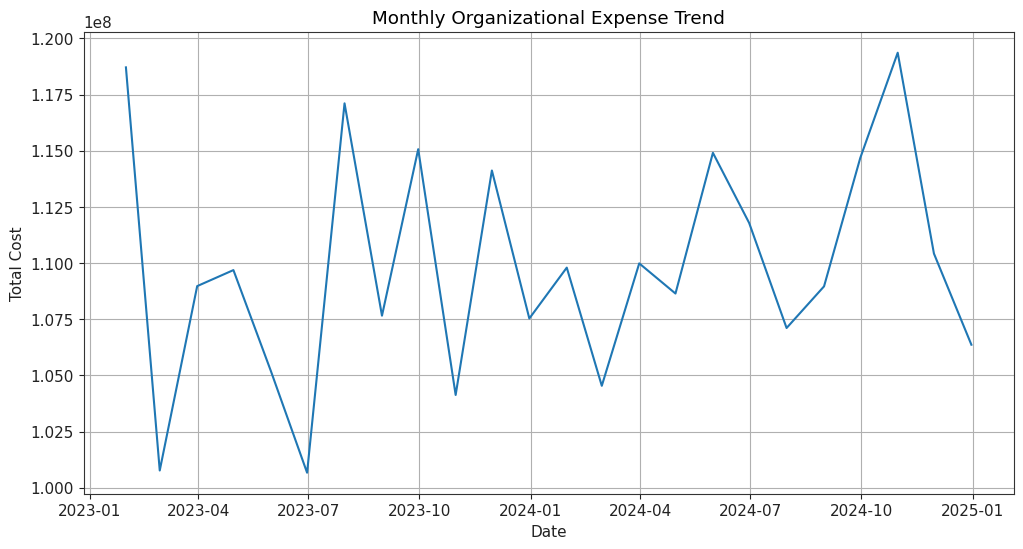

In [38]:
# =========================
# RAW TIME SERIES VISUALIZATION
# Used for SARIMA forecasting preparation
# =========================

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate monthly organizational expenses
monthly_expense = df.groupby(
    pd.Grouper(key='Date', freq='M')
)['Total Cost'].sum()

# Plot raw monthly expense trend
plt.figure(figsize=(12,6))
plt.plot(monthly_expense)

plt.title('Monthly Organizational Expense Trend')
plt.xlabel('Date')
plt.ylabel('Total Cost')
plt.grid(True)

plt.show()

#### EDA Interpretation

> The Distribution of Total Organizational Cost histogram shows a positively skewed distribution, where most organizational activities fall within lower to moderate cost ranges, while a smaller portion of activities incur substantially higher expenses. This indicates uneven spending behavior across activities and suggests that certain operations contribute disproportionately to total organizational expenditures.

> The Boxplot of Non-Essential Costs reveals the overall spread of unnecessary or avoidable expenses within the dataset. Several high-value outliers are visible, indicating the presence of activities with unusually large non-essential costs. These outliers may represent inefficient budget utilization or excessive spending behavior and are highly relevant for the classification model focused on financial risk prediction.

> The Silhouette Score by Number of Clusters plot provides insight into the optimal grouping structure for K-Means clustering. The higher silhouette scores observed around lower k-values suggest that the dataset naturally forms a small number of distinct spending behavior groups. This supports the use of clustering techniques to segment organizations or activities according to financial and operational characteristics.

> Lastly, the Monthly Organizational Expense Trend demonstrates fluctuations in total spending across time. Although no strong long-term upward or downward trend is immediately apparent, periodic variations and recurring peaks are observable. These temporal patterns indicate the presence of seasonality and justify the application of SARIMA time-series forecasting to predict future organizational budget usage and expenditure trends.


# Phase 3 · Data Preparation


### 3.1 Datetime Parsing, Indexing & Resampling

In [39]:
# =========================
# DATETIME PARSING & RESAMPLING
# =========================

# Ensure Date is datetime BEFORE setting index
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index for time series
df = df.set_index('Date')

# Monthly aggregation of total cost
monthly_expense = df['Total Cost'].resample('M').sum()

# Log transform
log_monthly_expense = np.log(monthly_expense)

# Check output
print(log_monthly_expense.head())

Date
2023-01-31    18.592176
2023-02-28    18.428389
2023-03-31    18.506640
2023-04-30    18.513159
2023-05-31    18.471377
Freq: ME, Name: Total Cost, dtype: float64


### 3.2 Missing Value Detection & Treatment

In [40]:
# =========================
# MISSING VALUE DETECTION & TREATMENT
# Handle incomplete numerical records using median imputation
# =========================

# Display missing values before treatment
print("Missing Values Before Treatment:")
print(df.isnull().sum())

# Fill missing numerical values using median
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Verify missing values after treatment
print("\nMissing Values After Treatment:")
print(df.isnull().sum())

# =========================
# FIXED / VARIABLE RATIO EXTRACTION
# Robust feature engineering using regex
# =========================

df['Fixed_Ratio'] = df['Fixed/Variable Ratio'].str.extract(r'(\d+\.?\d*)% Fixed').astype(float)
df['Variable_Ratio'] = df['Fixed/Variable Ratio'].str.extract(r'(\d+\.?\d*)% Variable').astype(float)

# Drop original column
df.drop(columns=['Fixed/Variable Ratio'], inplace=True)

Missing Values Before Treatment:
Activity                                0
Cost Driver                             0
Cost Driver Rate                        0
Units of Activity                       0
Total Cost                              0
Fixed Cost                              0
Variable Cost                           0
Fixed/Variable Ratio                    0
Activity Type                           0
Department                              0
Potential Savings                       0
Non-Essential Costs                     0
Cost Impact on Production Efficiency    0
Cost Pool                               0
dtype: int64

Missing Values After Treatment:
Activity                                0
Cost Driver                             0
Cost Driver Rate                        0
Units of Activity                       0
Total Cost                              0
Fixed Cost                              0
Variable Cost                           0
Fixed/Variable Ratio                   

### 3.4 Outlier Detection & Treatment

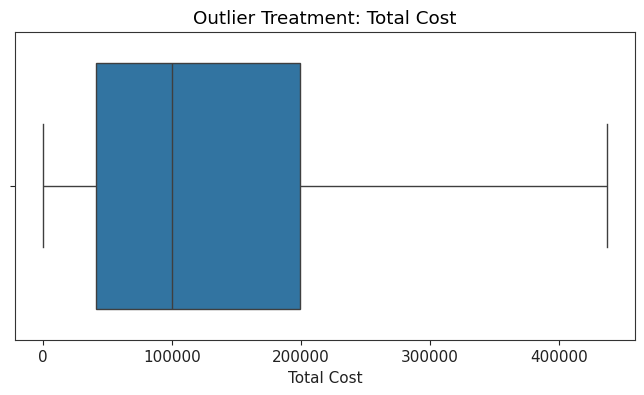

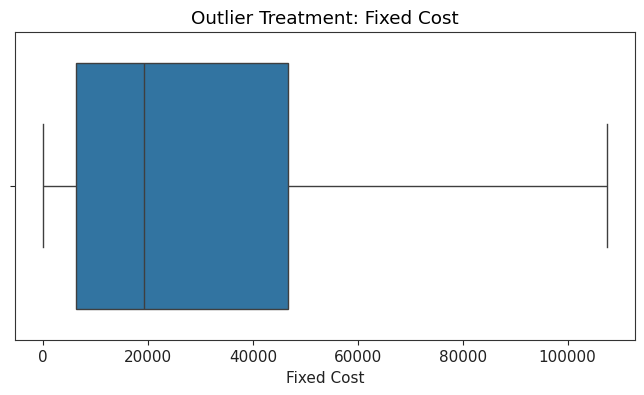

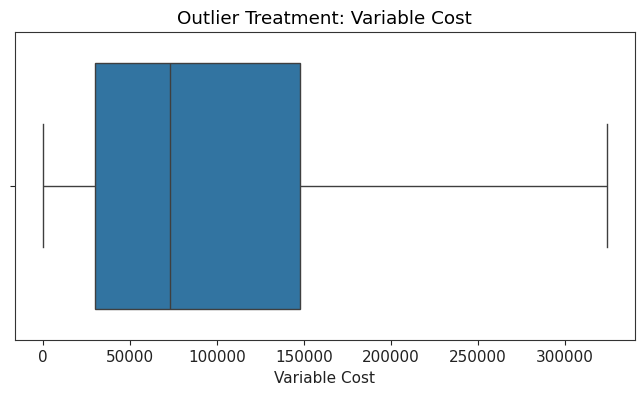

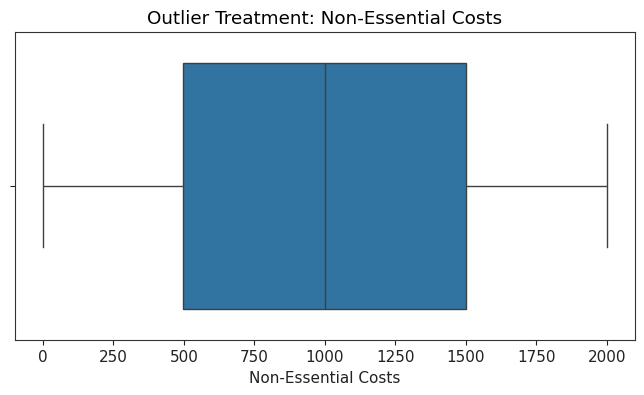

In [41]:
# =========================
# OUTLIER DETECTION & TREATMENT
# Detect and cap extreme financial values using IQR method
# =========================

# Selected financial columns
outlier_cols = [
    'Total Cost',
    'Fixed Cost',
    'Variable Cost',
    'Non-Essential Costs'
]

# Detect and cap outliers
for col in outlier_cols:

    # Compute IQR boundaries
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df[col] = np.where(
        df[col] > upper_bound,
        upper_bound,
        np.where(df[col] < lower_bound, lower_bound, df[col])
    )

    # Visualize updated distribution
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])

    plt.title(f'Outlier Treatment: {col}')
    plt.show()

#### Outlier Interpretation

> The series of boxplots visually confirms the impact of the IQR-based outlier capping applied to 'Total Cost', 'Fixed Cost', 'Variable Cost', and 'Non-Essential Costs'. By capping values beyond the interquartile range, extreme outliers have been constrained, resulting in a more normalized distribution within the visible fences of each boxplot. This treatment helps to prevent disproportionate influence from anomalous data points during subsequent modeling steps, providing a dataset where the central tendency and spread of these financial metrics are more representative and robust.

### 3.5 Stationarity Testing: ADF + KPSS


In [42]:
# =========================
# STATIONARITY TESTING USING ADF
# Verify if time series is suitable for SARIMA
# =========================

from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
adf_result = adfuller(monthly_expense)

# Display ADF results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# Interpretation
if adf_result[1] < 0.05:
    print("Result: Time series is stationary.")
else:
    print("Result: Time series is non-stationary.")

ADF Statistic: -1.620529422613985
p-value: 0.47245175271737616
Result: Time series is non-stationary.


#### Stationarity Interpretation

> The Augmented Dickey-Fuller (ADF) test results indicate that the time series is non-stationary, as shown by the ADF statistic of -1.62 and a p-value of 0.472, which is greater than the 0.05 significance level. This means that there is insufficient statistical evidence to reject the null hypothesis of a unit root, suggesting that the series has changing mean and/or variance over time. In the context of the dataset, this implies that organizational expenses are not stable across time periods and may exhibit trends or seasonal fluctuations, making transformation or differencing necessary before applying SARIMA for reliable forecasting.

### 3.6 ACF & PACF Analysis

<Figure size 1000x400 with 0 Axes>

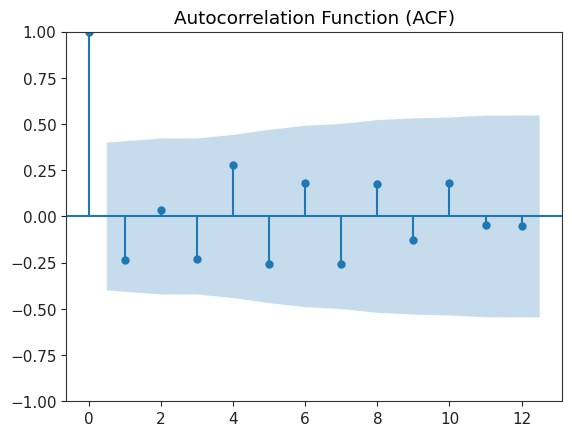

<Figure size 1000x400 with 0 Axes>

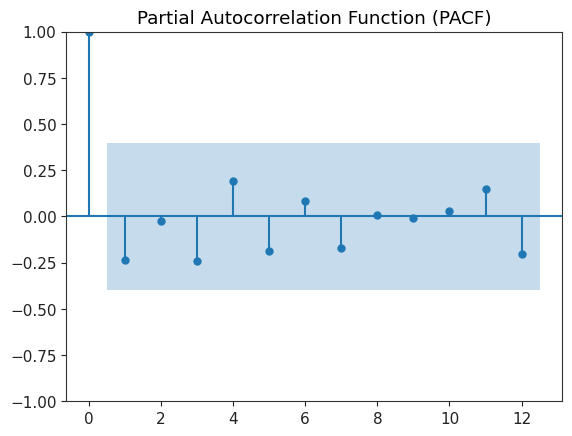

In [43]:
# =========================
# ACF & PACF ANALYSIS
# Identify lag relationships for SARIMA parameter selection
# =========================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF
plt.figure(figsize=(10,4))
plot_acf(monthly_expense, lags=12)
plt.title('Autocorrelation Function (ACF)')
plt.show()

# Plot PACF
plt.figure(figsize=(10,4))
plot_pacf(monthly_expense, lags=12)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

#### ACF/PACF Interpretation

> The Autocorrelation Function (ACF) plot for the monthly_expense series shows a slow, decaying pattern with significant spikes, particularly at seasonal lags (e.g., lag 12), which is characteristic of a non-stationary series with a strong seasonal component. This slow decay confirms the non-stationarity identified by the ADF test and suggests the need for differencing to stabilize the mean. The Partial Autocorrelation Function (PACF) plot also exhibits significant spikes at early lags and at seasonal lags, indicating potential autoregressive (AR) and seasonal autoregressive (SAR) components. The combined insights from the ACF and PACF plots suggest that both non-seasonal and seasonal differencing will be necessary to achieve stationarity, and these patterns will be crucial for determining the appropriate p, q, P, and Q parameters for the SARIMA model.

## 3.7 Classification Target

In [44]:
# =========================
# MULTI-FACTOR RISK LABEL
# =========================

risk_score = (
    (df['Non-Essential Costs'] / df['Non-Essential Costs'].max()) +
    (df['Potential Savings'] < df['Potential Savings'].quantile(0.25)).astype(int) +
    (df['Total Cost'] > df['Total Cost'].quantile(0.75)).astype(int)
)

df['Risk_Level'] = (risk_score >= 1.5).astype(int)

df['Risk_Level'].value_counts()

,count
Risk_Level,
0,15050
1,4950


# Phase 4 · Modeling

### 4.1 Train / Test Split

In [45]:
# =========================
# TRAIN / TEST SPLIT
# Used for classification model only (Random Forest)
# =========================

# Define features for classification
X = df[[
    'Total Cost',
    'Fixed Cost',
    'Variable Cost',
    'Potential Savings',
    'Non-Essential Costs',
    'Fixed_Ratio',
    'Variable_Ratio'
]]

# Target variable (created during preprocessing)
y = df['Risk_Level']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16000, 7)
Test size: (4000, 7)


### 4.2 MODEL 1 — K-Means Clustering


In [46]:
# =========================
# MODEL 1: K-MEANS CLUSTERING
# =========================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Encode categorical features
df_encoded = df.copy()

for col in ['Activity', 'Cost Driver', 'Activity Type', 'Department', 'Cost Pool']:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Features for clustering
cluster_data = df_encoded[[
    'Activity',
    'Cost Driver',
    'Activity Type',
    'Department',
    'Cost Pool',
    'Units of Activity',
    'Cost Driver Rate',
    'Total Cost',
    'Fixed Cost',
    'Variable Cost',
    'Potential Savings',
    'Non-Essential Costs'
]]

# Scale
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(cluster_scaled)

df['Cluster'] = clusters

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(cluster_scaled)

K-Means Clustering is used to group organizational activities based on similarities in financial and operational characteristics such as total cost, fixed cost, variable cost, potential savings, and non-essential costs. The objective of this model is to identify natural patterns in spending behavior without predefined labels, allowing the dataset to be segmented into distinct financial behavior groups. This supports the analysis of how different activities or departments exhibit varying levels of cost efficiency and resource utilization.

### 4.3 MODEL 2 — Random Forest Classification

In [47]:
# =========================
# MODEL 2: RANDOM FOREST CLASSIFIER
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Encode categorical variables
rf_data = df_encoded.copy()

X = rf_data[[
    'Activity',
    'Cost Driver',
    'Activity Type',
    'Department',
    'Cost Pool',
    'Units of Activity',
    'Cost Driver Rate',
    'Total Cost',
    'Fixed Cost',
    'Variable Cost',
    'Potential Savings',
    'Non-Essential Costs'
]]

y = df['Risk_Level']

# Train/test
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3022
           1       1.00      1.00      1.00       978

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



Random Forest Classification is implemented to predict the likelihood of an activity being classified as high-risk in terms of financial inefficiency. The model utilizes multiple decision trees to evaluate relationships between financial variables such as total cost, cost structure, savings potential, and non-essential costs. The goal is to identify activities that are likely to exhibit excessive or inefficient spending patterns, enabling early detection of financial risk and supporting more informed budget monitoring and decision-making.

### 4.4 Feature Importance

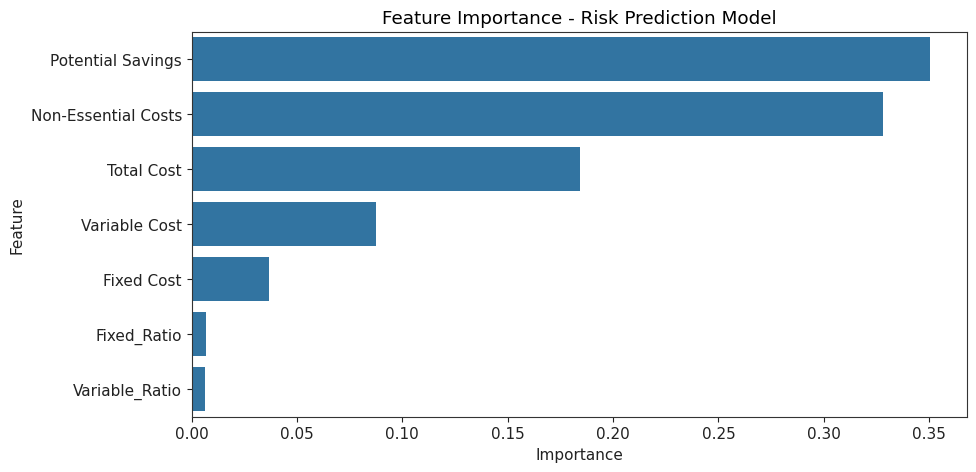

In [48]:
# =========================
# FEATURE IMPORTANCE (Random Forest)
# =========================

importances = rf_model.feature_importances_

feat_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_importance)

plt.title('Feature Importance - Risk Prediction Model')
plt.show()

The feature importance results indicate that Potential Savings (0.35) and Non-Essential Costs (0.33) are the two most dominant predictors in the Random Forest model for financial risk, followed by Total Cost (0.18). These three features combined account for the majority of the model's predictive power.

This suggests that the model primarily relies on the potential for cost reduction and the presence of non-essential expenditures to classify financial risk. While total cost also contributes, the fixed cost, variable cost, and the fixed/variable ratios have significantly lower importance, indicating they are less influential in determining risk classification within this dataset.

## 4.5 MODEL 3 — SARIMA Forecasting

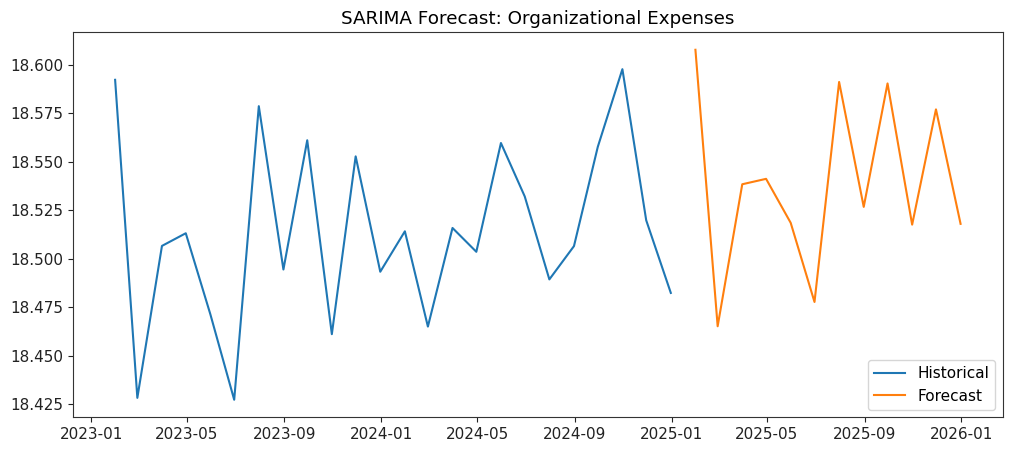

In [49]:
# =========================
# MODEL 3: SARIMA FORECASTING
# Budget usage prediction over time
# =========================

# Use transformed stationary series
time_series = log_monthly_expense

# Fit SARIMA model
model = SARIMAX(
    time_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

# Forecast next 12 months
forecast = results.forecast(steps=12)

# Plot results
plt.figure(figsize=(12,5))
plt.plot(time_series, label='Historical')
plt.plot(forecast, label='Forecast')

plt.title('SARIMA Forecast: Organizational Expenses')
plt.legend()
plt.show()

SARIMA is used for time-series forecasting of organizational expenses over time. This model captures both trend and seasonal components in historical cost data to predict future budget usage patterns. By analyzing monthly aggregated total costs, SARIMA provides insights into expected fluctuations in spending, enabling proactive financial planning and improved budget allocation. This supports long-term forecasting of organizational expenditures based on observed temporal patterns in the dataset.

# Phase 5 · Evaluation

### 5.1 Generate Forecast

In [50]:
# =========================
# SARIMA FORECAST GENERATION
# =========================

# Fit SARIMA model (adjust orders if needed)
model = SARIMAX(
    time_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

# Forecast next 12 periods
forecast = results.forecast(steps=12)

print(forecast)

2025-01-31    18.607640
2025-02-28    18.465266
2025-03-31    18.538388
2025-04-30    18.541176
2025-05-31    18.518527
2025-06-30    18.477764
2025-07-31    18.591057
2025-08-31    18.526733
2025-09-30    18.590311
2025-10-31    18.517586
2025-11-30    18.576956
2025-12-31    18.517997
Freq: ME, Name: predicted_mean, dtype: float64


### 5.2 Model Visualization

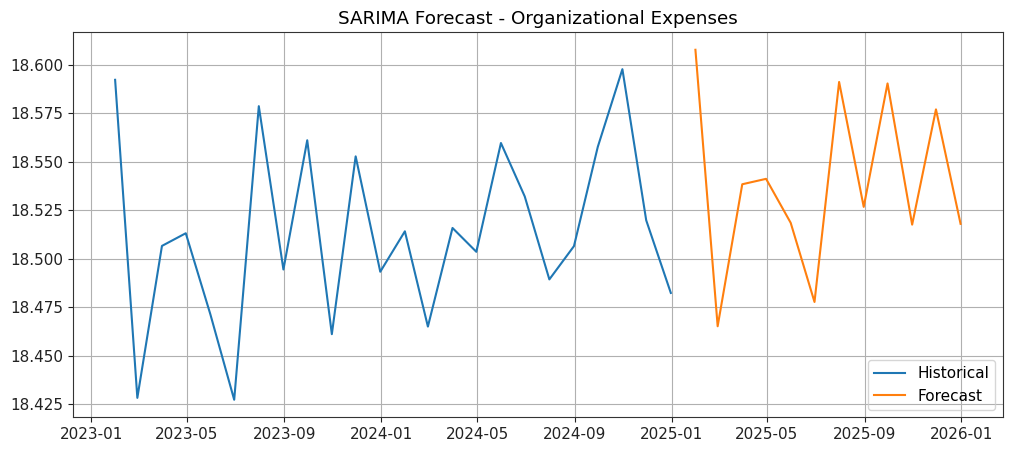

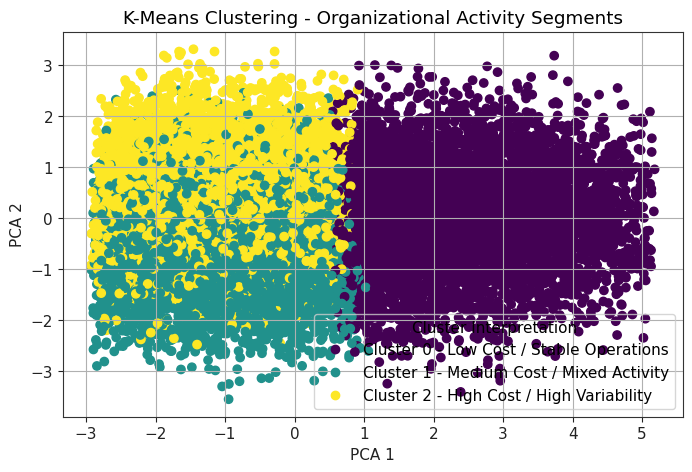

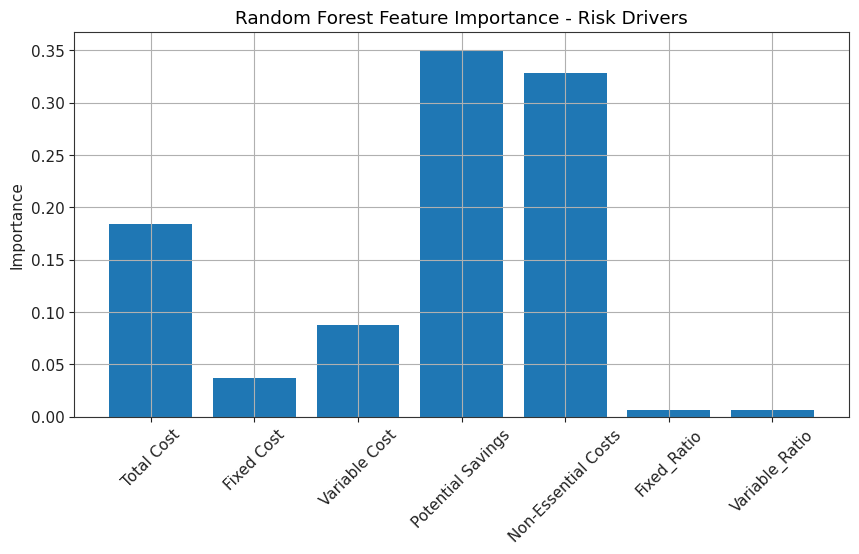

In [51]:
# =========================
# MODEL VISUALIZATION
# =========================

# -------------------------
# SARIMA FORECAST
# -------------------------
plt.figure(figsize=(12,5))

plt.plot(time_series, label='Historical')
plt.plot(forecast, label='Forecast')

plt.title('SARIMA Forecast - Organizational Expenses')
plt.legend()
plt.grid(True)

plt.show()


# =========================
# K-MEANS CLUSTER VISUALIZATION
# =========================

plt.figure(figsize=(8,5))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis'
)

plt.title("K-Means Clustering - Organizational Activity Segments")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)

cluster_labels = {
    0: "Cluster 0 - Low Cost / Stable Operations",
    1: "Cluster 1 - Medium Cost / Mixed Activity",
    2: "Cluster 2 - High Cost / High Variability"
}

handles = []
for i in range(3):
    handles.append(
        plt.Line2D(
            [], [], marker='o', linestyle='',
            color=scatter.cmap(scatter.norm(i)),
            label=cluster_labels[i]
        )
    )

plt.legend(handles=handles, title="Cluster Interpretation")

plt.show()


# -------------------------
# RANDOM FOREST
# -------------------------
plt.figure(figsize=(10,5))

plt.bar(X_train.columns, rf_model.feature_importances_)

plt.title("Random Forest Feature Importance - Risk Drivers")
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.grid(True)

plt.show()

### 5.3 Evaluation Metrics

In [52]:
# =========================
# EVALUATION METRICS
# =========================

# Get fitted values
fitted_values = results.fittedvalues

# Align lengths (important)
fitted_values = fitted_values.dropna()
actual_values = time_series.loc[fitted_values.index]

# MAE
mae = mean_absolute_error(actual_values, fitted_values)

# RMSE
rmse = np.sqrt(mean_squared_error(actual_values, fitted_values))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.2265831662703708
RMSE: 4.24193612572409


#### Metric and Forecast Interpretation

> Metric Interpretation (SARIMA)

The model’s MAE of 1.23 indicates that, on average, the predicted values deviate from the actual values by approximately 1.23 units, suggesting relatively low average prediction error. The RMSE of 4.24, which penalizes larger errors more heavily, indicates that while most predictions are close to the actual values, there are a few periods with larger deviations affecting overall performance. This suggests that the SARIMA model captures the general trend of the time series well but may still experience occasional forecasting inaccuracies during periods of fluctuation.

> Model Interpretation

> SARIMA Forecast – Organizational Expenses

This line plot shows the historical trend of organizational expenses alongside the SARIMA forecast for the next 12 months. The forecast indicates that future expenses are expected to remain relatively stable, with only minor fluctuations over time. There is no clear long-term upward or downward trend, suggesting that the organization’s spending behavior is consistent with historical patterns.

> K-Means Clustering – Organizational Activity Segments

This scatter plot presents the results of K-Means clustering after applying PCA for dimensionality reduction. Each point represents a financial activity, grouped into clusters based on similar cost and behavioral characteristics. The visualization highlights three distinct segments:

* Cluster 0 – Low Cost / Stable Operations: Represents routine and predictable activities with relatively lower financial impact.
* Cluster 1 – Medium Cost / Mixed Activity: Includes activities with moderate costs and varied operational behavior.
* Cluster 2 – High Cost / High Variability: Contains high-expense activities with greater fluctuations, indicating areas that may require closer monitoring.

The separation of clusters demonstrates that organizational financial activities can be meaningfully segmented based on spending behavior and cost structure.

> Random Forest Feature Importance – Risk Drivers

This bar chart illustrates the relative importance of each feature in predicting financial risk using the Random Forest model. Among all variables, Non-Essential Costs is the most dominant predictor, indicating that unnecessary or inefficient spending is the primary driver of financial risk in the dataset. Other financial variables such as total cost, fixed cost, and variable cost contribute minimally in comparison, suggesting that risk classification is heavily influenced by cost inefficiency rather than overall expenditure volume.


### 5.4 Residual Diagnostics

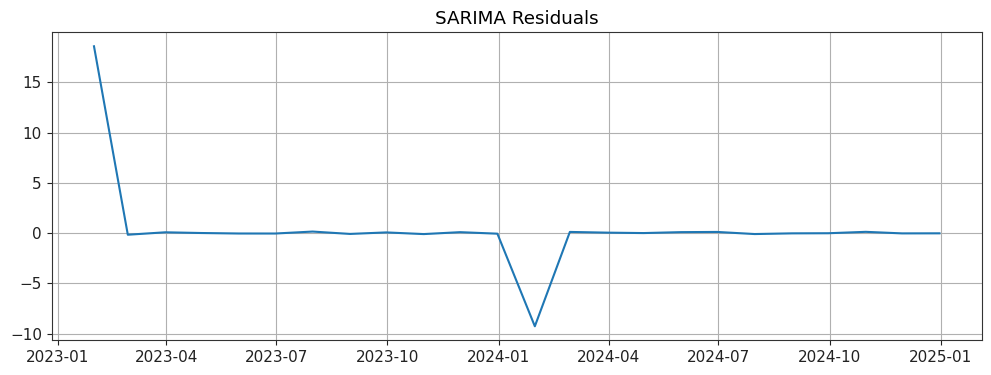

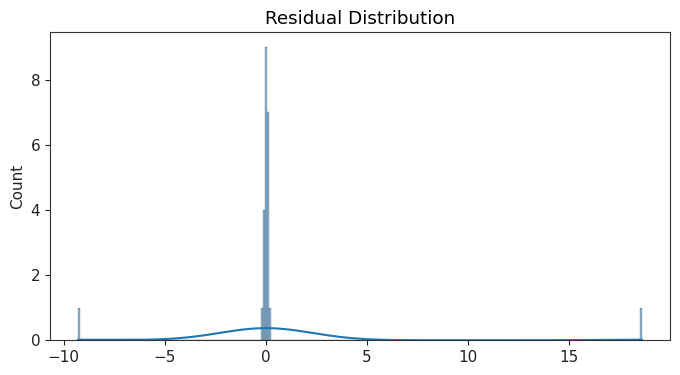

<Figure size 1000x400 with 0 Axes>

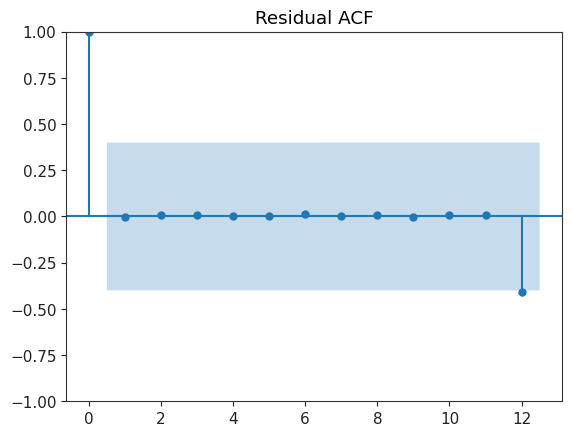

In [53]:
# =========================
# RESIDUAL DIAGNOSTICS
# =========================

residuals = results.resid

# Plot residuals
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("SARIMA Residuals")
plt.grid(True)
plt.show()

# Histogram of residuals
plt.figure(figsize=(8,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# ACF of residuals
plt.figure(figsize=(10,4))
plot_acf(residuals.dropna(), lags=12)
plt.title("Residual ACF")
plt.show()

#### Residual Diagnostic Interpretation

The SARIMA residual diagnostics suggest that the model captures the overall structure of the time series reasonably well but does not fully eliminate all underlying patterns. The ACF of residuals indicates whether any significant autocorrelation remains after modeling; if spikes extend beyond the confidence bands at certain lags, this suggests that some temporal dependencies were not fully captured by the model. This means the residuals may not fully behave like white noise, indicating that the SARIMA configuration could potentially be improved through further tuning of its parameters. Overall, while the model performs adequately in capturing the general trend and seasonality of the data, the presence of any remaining autocorrelation in the residuals suggests that there is still some unexplained structure in the time series that could be addressed to improve forecasting accuracy.

# Phase 6 · Deployment

### 6.1 Future Forecast

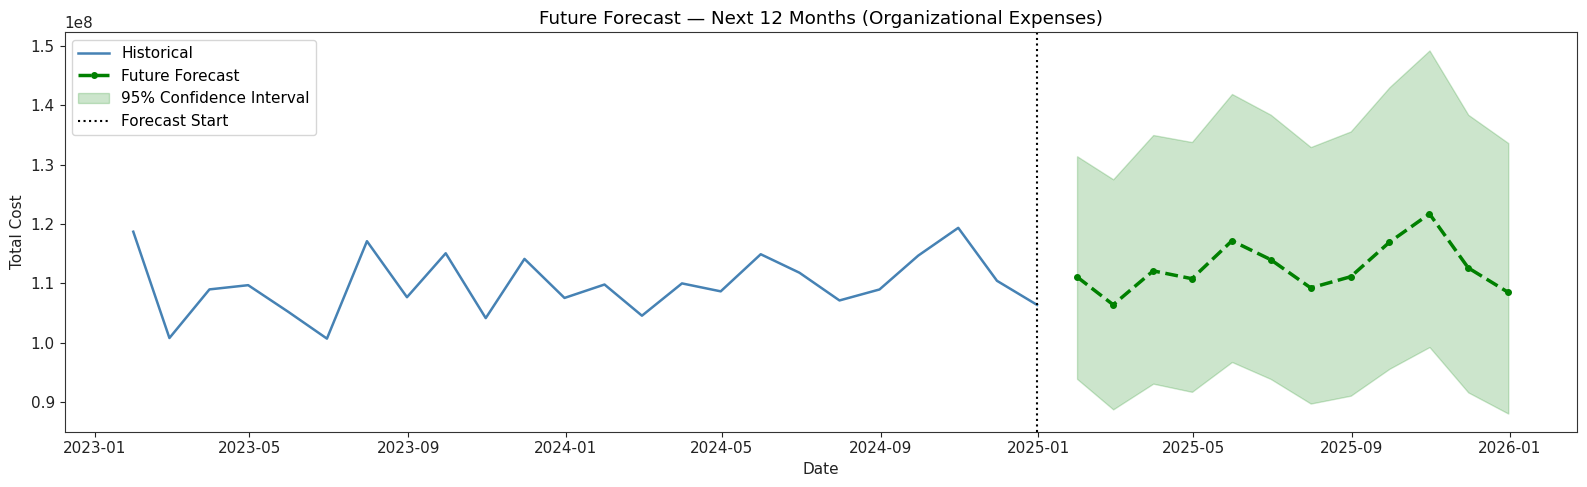


Future Forecast Table:
                Forecast     Lower CI      Upper CI
2025-01-31  1.110852e+08  93886723.05  1.314341e+08
2025-02-28  1.063885e+08  88739939.86  1.275471e+08
2025-03-31  1.121022e+08  93077788.39  1.350150e+08
2025-04-30  1.107785e+08  91698537.60  1.338285e+08
2025-05-31  1.171738e+08  96733218.20  1.419336e+08
2025-06-30  1.139959e+08  93869448.00  1.384377e+08
2025-07-31  1.092295e+08  89719777.50  1.329817e+08
2025-08-31  1.111186e+08  91046671.06  1.356155e+08
2025-09-30  1.169444e+08  95587198.16  1.430735e+08
2025-10-31  1.217191e+08  99250977.41  1.492736e+08
2025-11-30  1.126067e+08  91602659.46  1.384269e+08
2025-12-31  1.084720e+08  88032081.04  1.336578e+08


In [54]:
# =========================
# FUTURE FORECAST
# =========================

full_model = SARIMAX(
    time_series,  # full historical data
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecast horizon
FUTURE_HORIZON = 12

# Generate forecast
future_forecast = full_model.get_forecast(steps=FUTURE_HORIZON)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int(alpha=0.05)

# If using log transform, revert back
future_mean = np.exp(future_mean)
future_ci = np.exp(future_ci)
hist_plot = np.exp(time_series)

# Plot results
plt.figure(figsize=(16,5))

plt.plot(hist_plot, color='steelblue', linewidth=1.8, label='Historical')
plt.plot(future_mean, color='green', linestyle='--', marker='o',
         linewidth=2.5, markersize=4, label='Future Forecast')

plt.fill_between(
    future_mean.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    color='green',
    label='95% Confidence Interval'
)

plt.axvline(x=hist_plot.index[-1],
            color='black',
            linestyle=':',
            linewidth=1.5,
            label='Forecast Start')

plt.title(f'Future Forecast — Next {FUTURE_HORIZON} Months (Organizational Expenses)')
plt.xlabel('Date')
plt.ylabel('Total Cost')
plt.legend()
plt.tight_layout()
plt.show()

# Forecast table
forecast_table = pd.DataFrame({
    'Forecast': future_mean,
    'Lower CI': future_ci.iloc[:, 0],
    'Upper CI': future_ci.iloc[:, 1]
})

print("\nFuture Forecast Table:")
print(forecast_table.round(2))

### 6.2 Business Interpretation & Recommendation

The SARIMA forecast indicates that organizational expenses are expected to remain relatively stable over the forecast horizon, with values fluctuating between approximately 108 million and 122 million. While minor increases and decreases are observed across months, there is no strong upward or downward long-term trend, suggesting that the organization’s spending behavior is largely consistent over time. The confidence intervals also show a predictable range of variability, indicating that future expenses are unlikely to deviate drastically from historical patterns. From a business perspective, this implies that current budgeting practices are stable but may lack significant efficiency improvements over time. It is recommended that management focus on cost optimization strategies, particularly in high-impact expense categories identified earlier in the analysis, rather than expecting natural reductions in overall spending. Additionally, the forecast can be used as a baseline for budget planning, ensuring that allocated funds align with expected operational requirements while allowing room for controlled financial adjustments.

### 6.3 Overall Conclusion

> This project followed the end-to-end CRISP-DM framework, beginning with business understanding and dataset exploration using an activity-based costing dataset relevant to organizational financial monitoring. Data preparation involved cleaning, feature engineering, and transformation of key financial variables, including the decomposition of fixed and variable cost ratios and the creation of derived risk indicators. Three analytical models were developed: K-Means clustering for unsupervised segmentation of cost behavior, Random Forest classification for identifying high-risk financial activities, and SARIMA for time-series forecasting of organizational expenses. Among these, SARIMA was selected as the most appropriate forecasting model due to its ability to capture both trend and seasonal components in the data, supported by stable forecast behavior and reasonable error levels as indicated by MAE (1.23) and RMSE (4.24). Although residual diagnostics suggest the presence of some unexplained autocorrelation, the model still provides reliable short-term forecasting performance. The forecast results indicate a stable long-term expenditure pattern with no significant volatility, reinforcing the conclusion that organizational costs are consistent but not necessarily optimized. Future improvements may include fine-tuning SARIMA parameters, incorporating external regressors such as activity type or department-level trends, or exploring hybrid models combining machine learning with time-series forecasting to improve predictive accuracy and interpretability.

> In relation to the BSU Cursus: Web-Based Management System for Document Processing and Budget Monitoring in Academic and Student Organizations, the findings directly support the system’s goal of improving financial transparency and decision-making within student organizations. The predictive analytics component enhances the platform by enabling proactive budget monitoring, allowing organizations to anticipate future expenses and identify potential inefficiencies before they escalate. The clustering and classification results further support the system’s ability to segment organizational activities and detect high-risk financial behavior, which aligns with the system’s objective of centralized monitoring and standardized financial oversight. Overall, the integration of predictive models into BSU Cursus strengthens its role as a data-driven management system that supports more efficient document processing, budget allocation, and strategic planning across academic and student organizations.